# Network Intrusion Detection — Comparative Study

**Module:** STW7072CEM Machine Learning  
**Author:** Sudip Adhikari (250578)  
**Institution:** Softwarica College of IT & E-Commerce (Coventry University)

This notebook is the runnable companion to the paper. It loads the NSL-KDD
benchmark, preprocesses it, trains three classical machine-learning
algorithms (Logistic Regression, Random Forest, XGBoost) under identical
conditions, and evaluates them on the held-out KDDTest+ split.

It re-uses the modules in `../src/` rather than duplicating logic, so the
code in the paper, the notebook, and the script are all one and the same.

---
## Step 0 — Setup

Before running this notebook:

1. Install the dependencies: `pip install -r ../requirements.txt`
2. On macOS, install OpenMP for XGBoost: `brew install libomp`
3. Download the NSL-KDD dataset and place `KDDTrain+.txt` and `KDDTest+.txt` 
   under `../dataset/archive/nsl-kdd/`.
   - Kaggle: <https://www.kaggle.com/datasets/hassan06/nslkdd>
   - UNB original: <https://www.unb.ca/cic/datasets/nsl.html>

In [1]:
# Make src/ importable
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

from config import CLASS_LABELS, CV_FOLDS, RANDOM_SEED
from data_loader import load_nsl_kdd, class_distribution
from preprocess import full_pipeline
from models import build_models
from evaluate import overall_metrics, per_class_table

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)
print('Imports OK. Random seed:', RANDOM_SEED)

Imports OK. Random seed: 42


## Step 1 — Load NSL-KDD

The loader reads the raw KDDTrain+ / KDDTest+ files, attaches the 41 column
names, and maps the 22 specific attack labels into five high-level classes:
**Normal**, **DoS**, **Probe**, **R2L**, **U2R**.

In [2]:
train_df, test_df = load_nsl_kdd()
print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
print()
print(class_distribution(train_df, 'train'))
print()
print(class_distribution(test_df,  'test'))

Train shape: (125973, 42)
Test  shape: (22544, 42)

               samples  percent
class (train)                  
Normal           67343    53.46
DoS              45927    36.46
Probe            11656     9.25
R2L                995     0.79
U2R                 52     0.04

              samples  percent
class (test)                  
Normal           9711    43.08
DoS              7458    33.08
R2L              2887    12.81
Probe            2421    10.74
U2R                67     0.30


### Class imbalance

The class distribution is severely skewed. U2R has only 52 training records
(0.04 %) — three orders of magnitude smaller than the Normal class.
Equally important, R2L jumps from 0.79 % in train to 12.81 % in test:
**NSL-KDD deliberately includes attack subtypes in the test set that are absent or under-represented in training.** This is what makes the benchmark realistic.

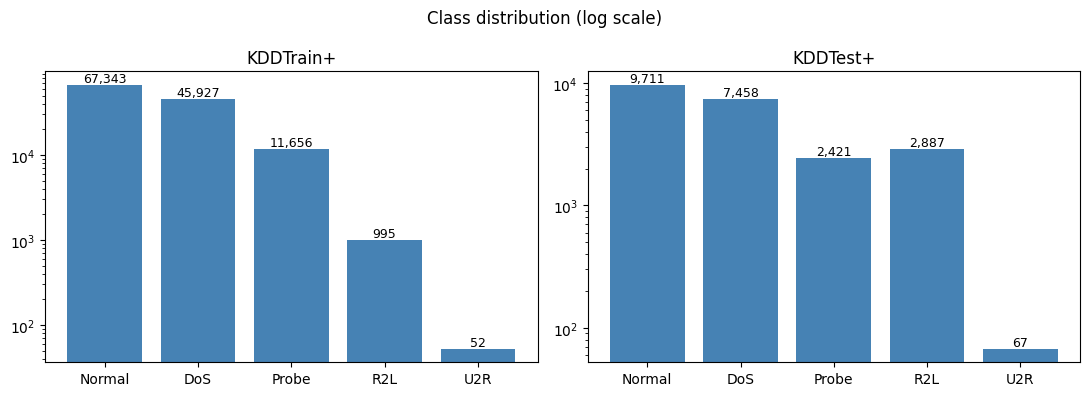

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, title in zip(axes, [train_df, test_df], ['KDDTrain+', 'KDDTest+']):
    counts = df['label'].value_counts().reindex(CLASS_LABELS)
    ax.bar(counts.index, counts.values, color='steelblue')
    ax.set_title(title); ax.set_yscale('log')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Class distribution (log scale)')
fig.tight_layout(); plt.show()

## Step 2 — Preprocessing

Three categorical columns (`protocol_type`, `service`, `flag`) are one-hot
encoded over the **union of train and test categories** so that any service
string that appears only in the test set still gets a column. The remaining
38 numeric features are then standardised (zero mean, unit variance) using a
scaler fit only on the training data.

After encoding, the feature dimensionality grows from 41 → 122.

In [4]:
X_train, y_train, X_test, y_test, feature_names, _ = full_pipeline(train_df, test_df)
print('Feature matrix:', X_train.shape, '(train)', X_test.shape, '(test)')
print('Class index → label:', dict(enumerate(CLASS_LABELS)))

Feature matrix: (125973, 122) (train) (22544, 122) (test)
Class index → label: {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}


## Step 3 — Class imbalance handling: SMOTE

SMOTE creates synthetic minority examples by interpolating between real
minority samples and their nearest neighbours. We apply it in two places:

1. **Inside each cross-validation fold**, on the training side only, so the
   validation fold remains untouched and CV scores are honest.
2. **Once globally** for the final fit, *after* CV is complete.

Generating SMOTE samples once before splitting is a common shortcut that
leaks information into validation folds and inflates CV scores.

In [5]:
def cv_with_smote(model, X, y, cv_folds=CV_FOLDS):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X[tr], X[va]
        y_tr, y_va = y[tr], y[va]
        # k_neighbors must be <= (smallest class count - 1)
        k = max(1, min(5, pd.Series(y_tr).value_counts().min() - 1))
        X_res, y_res = SMOTE(random_state=RANDOM_SEED, k_neighbors=k).fit_resample(X_tr, y_tr)
        m = clone(model).fit(X_res, y_res)
        s = f1_score(y_va, m.predict(X_va), average='weighted', zero_division=0)
        scores.append(s)
        print(f'  fold {fold}/{cv_folds}: weighted F1 = {s:.4f}')
    return float(np.mean(scores)), float(np.std(scores))

# Final-fit resample (after CV is complete)
X_train_smote, y_train_smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5).fit_resample(X_train, y_train)
print('After SMOTE:', X_train_smote.shape[0], 'rows')
print('Class counts:', dict(pd.Series(y_train_smote).value_counts().sort_index()))

After SMOTE: 336715 rows
Class counts: {0: np.int64(67343), 1: np.int64(67343), 2: np.int64(67343), 3: np.int64(67343), 4: np.int64(67343)}


## Step 4 — Define the three models

Hyperparameters are deliberately conservative; we are studying *baseline*
behaviour rather than chasing leaderboard scores. Heavy tuning would muddle
the comparison because each algorithm has different sensitivity to its
hyperparameter space.

- **Logistic Regression** — linear baseline, multinomial with L-BFGS
- **Random Forest** — bagging ensemble, 100 trees, class-weight balanced
- **XGBoost** — gradient boosting, 200 trees, depth 6, learning rate 0.1

In [6]:
models = build_models()
for name, m in models.items():
    print(f'{name:>22s} → {type(m).__name__}')

   Logistic Regression → LogisticRegression
         Random Forest → RandomForestClassifier
               XGBoost → XGBClassifier


## Step 5 — Train, cross-validate, and evaluate

For each model we (a) run the per-fold-SMOTE CV, (b) refit on the full
SMOTE-resampled training set, and (c) evaluate on the untouched KDDTest+
split. Per-class metrics are reported because overall accuracy is misleading
on data this imbalanced.

**Note**: training takes 5–10 minutes total (Logistic Regression is the
slowest because of the saturated SMOTE-resampled feature matrix).

In [7]:
comparison_rows = []
for name, model in models.items():
    print(f'\n--- {name} ---')
    t0 = time.time()
    print('  Cross-validating (5-fold, SMOTE per fold)...')
    cv_mean, cv_std = cv_with_smote(model, X_train, y_train)
    print(f'  CV weighted F1: {cv_mean:.4f} ± {cv_std:.4f}')

    print('  Fitting on full SMOTE-resampled train set...')
    model.fit(X_train_smote, y_train_smote)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    overall   = overall_metrics(y_test, y_pred, y_proba)
    per_class = per_class_table(y_test, y_pred)
    overall.update({
        'model': name,
        'cv_f1_weighted_mean': cv_mean,
        'cv_f1_weighted_std':  cv_std,
        'wall_time_seconds':   round(time.time() - t0, 1),
    })
    comparison_rows.append(overall)
    print(f"  Test accuracy: {overall['accuracy']:.4f} | weighted F1: {overall['f1_weighted']:.4f} | macro F1: {overall['f1_macro']:.4f}")
    print('  Per-class:')
    print(per_class.round(4).to_string())


--- Logistic Regression ---
  Cross-validating (5-fold, SMOTE per fold)...


/Users/sudipadh/Desktop/PERSONAL/masters/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 1/5: weighted F1 = 0.9777


/Users/sudipadh/Desktop/PERSONAL/masters/machine_learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  fold 2/5: weighted F1 = 0.9766


...

  fold 2/5: weighted F1 = 0.9991


  fold 3/5: weighted F1 = 0.9994


  fold 4/5: weighted F1 = 0.9991


  fold 5/5: weighted F1 = 0.9988
  CV weighted F1: 0.9991 ± 0.0002
  Fitting on full SMOTE-resampled train set...


  Test accuracy: 0.7866 | weighted F1: 0.7582 | macro F1: 0.6337
  Per-class:
        precision  recall  f1-score  support
Normal     0.6936  0.9719    0.8095   9711.0
DoS        0.9641  0.8073    0.8788   7458.0
Probe      0.8209  0.7518    0.7848   2421.0
R2L        0.9818  0.1496    0.2597   2887.0
U2R        0.6471  0.3284    0.4356     67.0


## Step 6 — Final comparison

The table below is the headline result. Things to look for:

1. **XGBoost wins on accuracy, macro F1, and ROC-AUC** — the metrics that matter most on imbalanced data.
2. **Random Forest is the fastest** to train but weakest on rare classes.
3. **Logistic Regression is competitive on weighted F1**, but the per-class
   tables will show this is a majority-class effect, not genuine R2L/U2R skill.
4. **All three models show CV F1 ≈ 0.97–0.99 but test F1 ≈ 0.71–0.76** — a
   ~22-percentage-point gap that the paper attributes to NSL-KDD's
   deliberate inclusion of unseen attack subtypes in the test split.

In [8]:
df = pd.DataFrame(comparison_rows)
cols = ['model', 'accuracy', 'precision_weighted', 'recall_weighted',
        'f1_weighted', 'f1_macro', 'roc_auc_ovr',
        'cv_f1_weighted_mean', 'wall_time_seconds']
df[cols].round(4)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc_ovr,cv_f1_weighted_mean,wall_time_seconds
0,Logistic Regression,0.7791,0.8018,0.7791,0.7631,0.5745,0.8970,0.9756,372.0
1,Random Forest,0.7505,0.8134,0.7505,0.7112,0.5382,0.9476,0.9987,63.1
2,XGBoost,0.7866,0.8335,0.7866,0.7582,0.6337,0.9537,0.9991,102.8


## Step 7 — Confusion matrix and feature importance for the best model (XGBoost)

The confusion matrix tells us *where* the errors land. The feature-importance
plot tells us *why* the model decides what it decides.

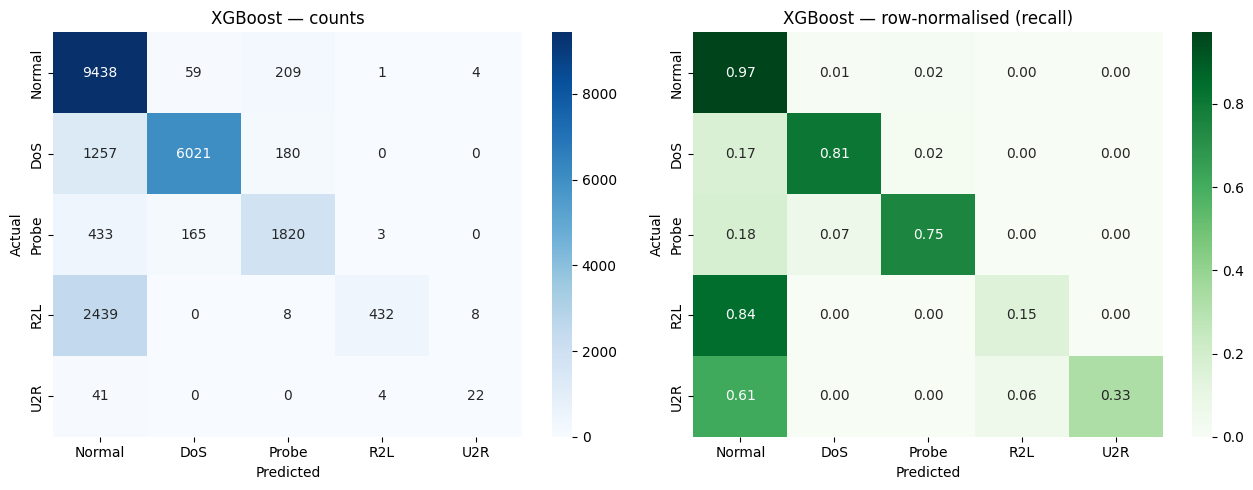

In [9]:
from sklearn.metrics import confusion_matrix
best_name = df.loc[df['f1_macro'].idxmax(), 'model']
best_model = models[best_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm,      annot=True, fmt='d',     cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=axes[0])
axes[0].set_title(f'{best_name} — counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=axes[1])
axes[1].set_title(f'{best_name} — row-normalised (recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
fig.tight_layout(); plt.show()

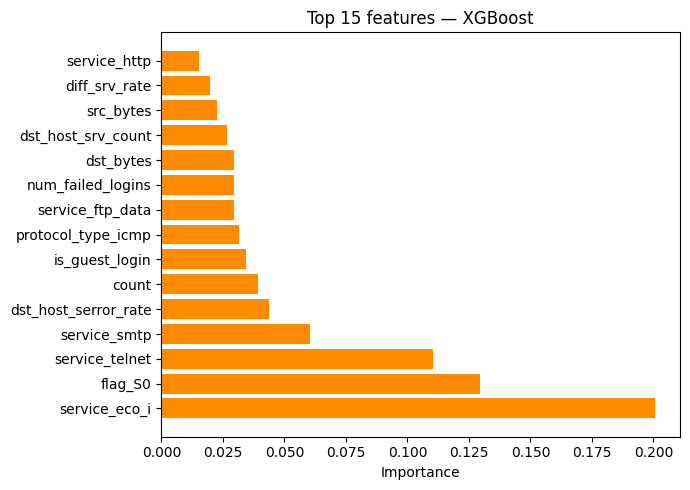

In [10]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-15:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = importances[top_idx]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(range(len(top_idx))[::-1], top_vals[::-1], color='darkorange')
    ax.set_yticks(range(len(top_idx))[::-1]); ax.set_yticklabels(top_names[::-1])
    ax.set_xlabel('Importance'); ax.set_title(f'Top 15 features — {best_name}')
    fig.tight_layout(); plt.show()

## Step 8 — Take-aways

1. **XGBoost is the strongest baseline** on this benchmark, with the best
   accuracy (78.7 %), macro F1 (0.6337), and ROC-AUC (0.954). It is the only
   model with non-trivial U2R detection (F1 ≈ 0.44).

2. **R2L remains hard for everybody.** Even the best model recalls only
   ~15 % of R2L attacks. Classical-ML detectors should not be the sole
   defence against R2L-class threats.

3. **The CV-vs-test gap is the single biggest effect** in the experiment —
   bigger than any difference between models. Studies that quote only CV
   scores are reporting the wrong number.

4. **Feature importance points to monitorable signals** — connection flags,
   service strings, error rates. The model's reasoning is auditable rather
   than opaque.

Full discussion, including the social/ethical/legal/professional implications
of deploying such a detector, is in `../research_paper/paper.pdf`.